1. Read the data - in .csv data

In [9]:
import os
import pandas as pd

for file in os.listdir("../data"):
    df = pd.read_parquet(f"../data/{file}")
    csv_file_name = file.replace(".parquet", ".csv")
    df.to_csv(f"csv_data/{csv_file_name}", index=False)

In [ ]:
lidar_data_df = pd.read_parquet("../data/lidar_cable_points_easy.parquet")
print(lidar_data_df.head())
print(lidar_data_df.columns)
print(lidar_data_df.shape)

              x          y          z
2211   6.196634 -13.157755  10.582272
2905 -10.440643  17.264460  10.926065
1411   2.977432  -3.552676  10.072814
251    5.924494 -10.974960  10.342501
794   -7.062873  12.850664  10.557997
Index(['x', 'y', 'z'], dtype='object')
(1502, 3)


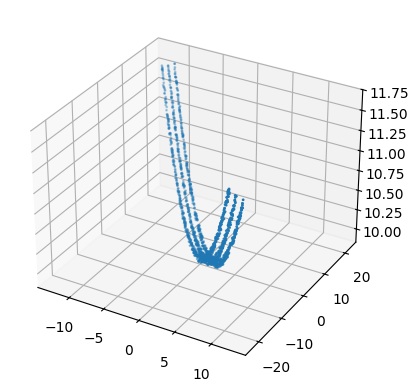

In [ ]:
# looks like x, y, z are the column coordinates, tr
import matplotlib.pyplot as plt
blank_canvas = plt.figure().add_subplot(111, projection="3d")
blank_canvas.scatter(lidar_data_df["x"], lidar_data_df["y"], lidar_data_df["z"], s=1)
plt.savefig("images/lidar_data_visualization.png")

3. Clustering

In [19]:
from sklearn.cluster import DBSCAN
coordinates = lidar_data_df[["x", "y", "z"]].values
db_scan = DBSCAN(eps=0.76, min_samples=5)
labels = db_scan.fit_predict(coordinates)
print(f"Unique clusters: {set(labels)}")

Unique clusters: {0, 1, 2}


4. Converting 3D->2D for one cluster

In [20]:
coordinates = lidar_data_df[["x", "y", "z"]].values
print(coordinates)

[[  6.19663435 -13.15775512  10.58227233]
 [-10.44064287  17.26446014  10.92606471]
 [  2.97743169  -3.55267568  10.0728142 ]
 ...
 [ -9.74456296  19.54896042  11.2729797 ]
 [ -2.06073546   5.73005863  10.09060331]
 [ 11.12628854 -18.49790267  11.07095826]]
